# Graves/Ring classification with Pegasos and SGD

This notebook downloads the `graves/ring` dataset from the Clustering Benchmarks suite,
trains `PegasosBaseline` and `SGDBaseline` from `SCS.py`, and visualizes predictions.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import importlib

import importlib
import SCS
importlib.reload(SCS)
from SCS import PegasosBaseline, SGDBaseline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [12]:
import genieclust
import numpy as np


import clustbench

def load_project_datasets(COLLECTIONS = ["sipu", "uci", "fcps", "graves"], data_path = "./../../clustering-data-v1"):
    datasets = {}
    for battery in COLLECTIONS:
        dataset_names = clustbench.get_dataset_names(battery=battery, path =data_path)
        for name in dataset_names:
            if name in ["birch1", "birch2", "worms_2", "worms_64"]:
                continue

            print(f"Loading {battery} datasets: {dataset_names}")
            dataset = clustbench.load_dataset(battery=battery, path=data_path, dataset=name)
            X = dataset.data
            y = dataset.labels[0]
            entry = {"X": X, "y": y, "K" : np.max(y)}
            datasets[f"{battery}/{name}"] = entry
    return datasets

In [13]:
datasets = load_project_datasets(COLLECTIONS=["graves"], data_path = "./../clustering-data-v1")

Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outliers', 'zigzag', 'zigzag_noisy', 'zigzag_outliers']
Loading graves datasets: ['dense', 'fuzzyx', 'line', 'parabolic', 'ring', 'ring_noisy', 'ring_outlie

In [14]:
datasets.keys()

dict_keys(['graves/dense', 'graves/fuzzyx', 'graves/line', 'graves/parabolic', 'graves/ring', 'graves/ring_noisy', 'graves/ring_outliers', 'graves/zigzag', 'graves/zigzag_noisy', 'graves/zigzag_outliers'])

In [15]:
from sklearn.model_selection import train_test_split

key = "graves/ring"

if key in datasets:
    data = datasets[key]
    X = data["X"]
    y = data["y"].astype(int)

In [30]:
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [28]:
pegasos = PegasosBaseline(gamma_rbf=0.5, verbose=False)
sgd = SGDBaseline(gamma_rbf=0.9, eta=0.001, verbose=False)

y = y.astype(int)
y_transformed = np.where(y == 2, -1, 1)
pegasos.fit(X, y_transformed, max_iter=300, precompute_kernel=False)
sgd.fit(X, y_transformed, max_iter=300, precompute_kernel=False)

pred_pegasos = pegasos.predict(X)
pred_sgd = sgd.predict(X)

acc_pegasos = np.mean(pred_pegasos == y_transformed)
acc_sgd = np.mean(pred_sgd == y_transformed)

print(f"Pegasos accuracy: {acc_pegasos:.3f}")
print(f"SGD accuracy:     {acc_sgd:.3f}")

Pegasos accuracy: 1.000
SGD accuracy:     0.903


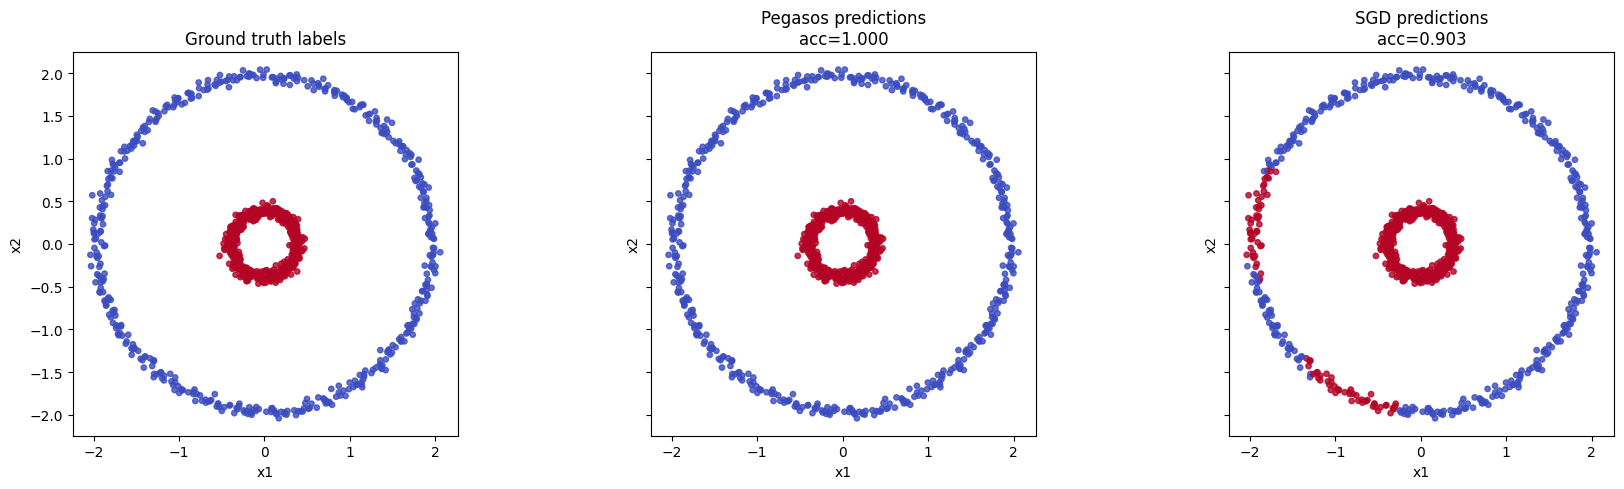

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

axes[0].scatter(X[:, 0], X[:, 1], c=y_transformed, cmap="coolwarm", s=15, alpha=0.8)
axes[0].set_title("Ground truth labels")

axes[1].scatter(X[:, 0], X[:, 1], c=pred_pegasos, cmap="coolwarm", s=15, alpha=0.8)
axes[1].set_title(f"Pegasos predictions\nacc={acc_pegasos:.3f}")

axes[2].scatter(X[:, 0], X[:, 1], c=pred_sgd, cmap="coolwarm", s=15, alpha=0.8)
axes[2].set_title(f"SGD predictions\nacc={acc_sgd:.3f}")

plt.tight_layout()
plt.show()

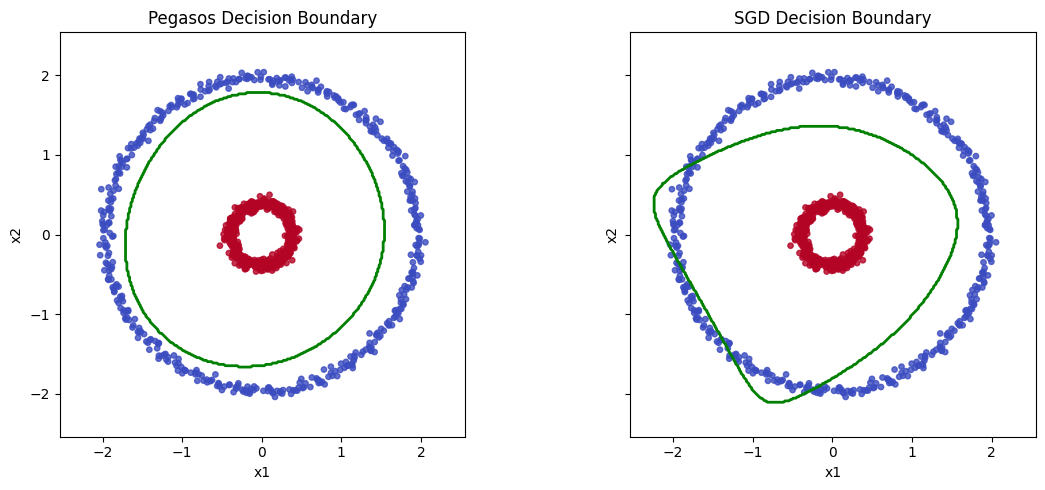

In [30]:
# Plot decision boundaries for Pegasos and SGD

def plot_decision_boundary(ax, model, X, title):
    # Create grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    # Predict on grid
    zz = model.predict(grid).reshape(xx.shape)
    # Plot contour
    ax.contour(xx, yy, zz, levels=[0], linewidths=2, colors="green")
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax in axes:
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

# Pegasos boundaries
axes[0].scatter(X[:, 0], X[:, 1], c=y_transformed, cmap="coolwarm", s=15, alpha=0.8, label="data")
plot_decision_boundary(axes[0], pegasos, X, f"Pegasos Decision Boundary")

# SGD boundaries
axes[1].scatter(X[:, 0], X[:, 1], c=y_transformed, cmap="coolwarm", s=15, alpha=0.8, label="data")
plot_decision_boundary(axes[1], sgd, X, f"SGD Decision Boundary")

plt.tight_layout()
plt.show()